In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [2]:
user_data = pd.read_csv('3_user_data.csv')

In [3]:
logs = pd.read_csv('3_logs.csv')

In [4]:
user_data 
user_data.isna().sum()
user_data

,client,premium,age
0,46346,False,58
1,4391,False,55
2,27372,False,64
3,11989,False,44
4,60664,False,49
...,...,...,...
2949,19411,False,29
2950,61579,False,50
2951,61221,True,64
2952,29863,False,46


In [5]:
logs
logs.dtypes
logs.isna().sum()
logs['platform'].unique()


array(['phone', 'computer', 'tablet'], dtype=object)

In [6]:
logs

,client,success,platform,time
0,40177,True,phone,1585412212
1,61468,True,phone,1585425658
2,35604,False,phone,1585459894
3,9961,True,phone,1585400189
4,10931,True,computer,1585468629
...,...,...,...,...
4495,64496,False,computer,1585459072
4496,73299,True,phone,1585458370
4497,8967,True,phone,1585465121
4498,52880,False,phone,1585455362


In [7]:
success_operations = logs[logs['success'] == True]. \
    groupby('client', as_index = False). \
    agg({'time': 'count'}). \
    rename(columns = {'time': 'total_operations'})

In [8]:
success_operations

,client,total_operations
0,40,1
1,50,1
2,75,1
3,81,1
4,132,1
...,...,...
2840,99926,1
2841,99927,1
2842,99931,1
2843,99973,1


In [9]:
mvc = success_operations[success_operations['total_operations'] == success_operations['total_operations'].max()]

In [10]:
print(', '.join(map(str, sorted(mvc['client']))))

12179, 28719, 36165, 52870, 61468, 61473, 78349, 82563, 92584


In [11]:
logs[logs['success'] == True].groupby('platform', as_index = False). \
    agg({'time': 'count'}). \
    rename(columns = {'time': 'suc_operations'})

,platform,suc_operations
0,computer,1090
1,phone,2019
2,tablet,180


In [12]:
df = user_data.merge(logs, on = 'client')

In [13]:
df

,client,premium,age,success,platform,time
0,46346,False,58,True,phone,1585452839
1,4391,False,55,False,phone,1585409861
2,27372,False,64,False,phone,1585446018
3,11989,False,44,True,computer,1585403698
4,60664,False,49,True,phone,1585406918
...,...,...,...,...,...,...
3434,19411,False,29,True,phone,1585400902
3435,61579,False,50,True,phone,1585436158
3436,61221,True,64,True,phone,1585440218
3437,29863,False,46,True,tablet,1585443437


In [14]:
premium_clients = df[df['premium'] == True]

In [15]:
premium_clients.groupby('platform'). \
    agg({'time': 'count'}). \
    rename(columns = {'time': 'num_of_operations'})

,num_of_operations
platform,
computer,150
phone,246
tablet,24


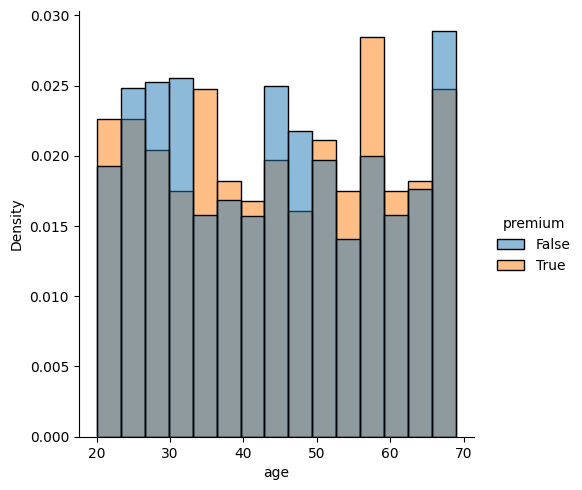

In [16]:
sns.displot(data = df, x = 'age', hue = 'premium', stat = 'density', common_norm = False)

<Axes: xlabel='total_operations', ylabel='count'>

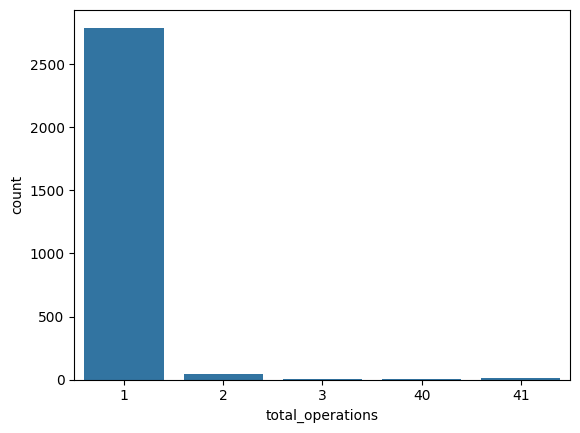

In [40]:
sns.countplot(data = success_operations, x = 'total_operations')

In [29]:
success_operations['total_operations'].unique()

array([ 1,  2, 41, 40,  3])

In [34]:
successes_comp = df[(df['success'] == True) & (df['platform'] == 'computer')]

In [35]:
successes_comp

,client,premium,age,success,platform,time
3,11989,False,44,True,computer,1585403698
12,32406,False,24,True,computer,1585479382
14,62404,False,40,True,computer,1585430097
20,68848,False,35,True,computer,1585440553
26,49675,False,48,True,computer,1585402108
...,...,...,...,...,...,...
3414,93718,False,63,True,computer,1585466349
3415,13688,True,66,True,computer,1585453923
3417,68348,False,69,True,computer,1585456739
3427,9450,False,34,True,computer,1585446079


In [37]:
successes_comp_by_age = successes_comp.groupby('age', as_index = False). \
    agg({'success': 'count'}). \
    rename(columns = ({'success': 'successes'}))

<Axes: xlabel='age', ylabel='successes'>

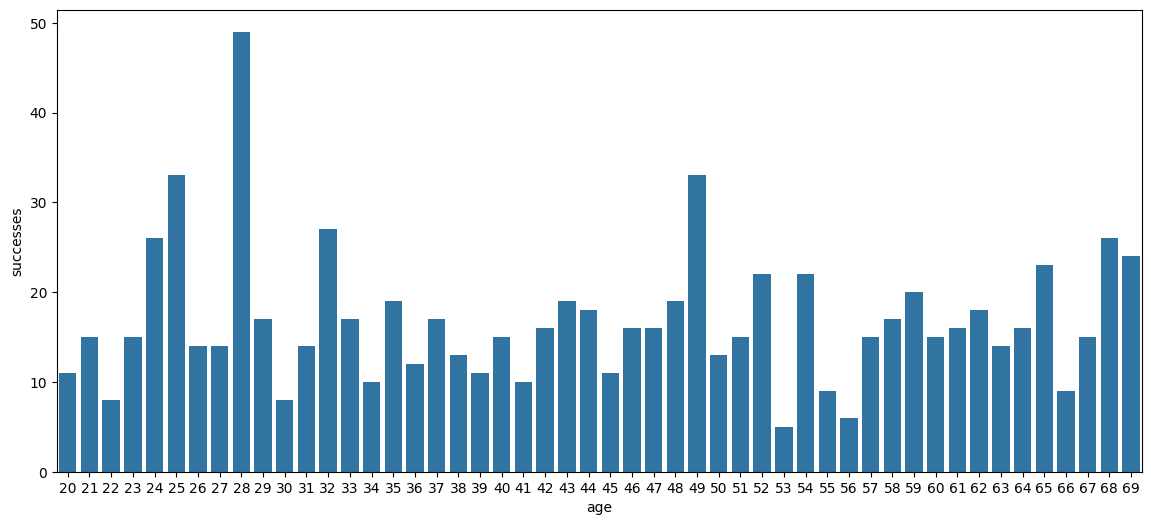

In [51]:
plt.figure(figsize=(14,6))
sns.barplot(data = successes_comp_by_age, x = 'age', y = 'successes')

<Axes: xlabel='age', ylabel='count'>

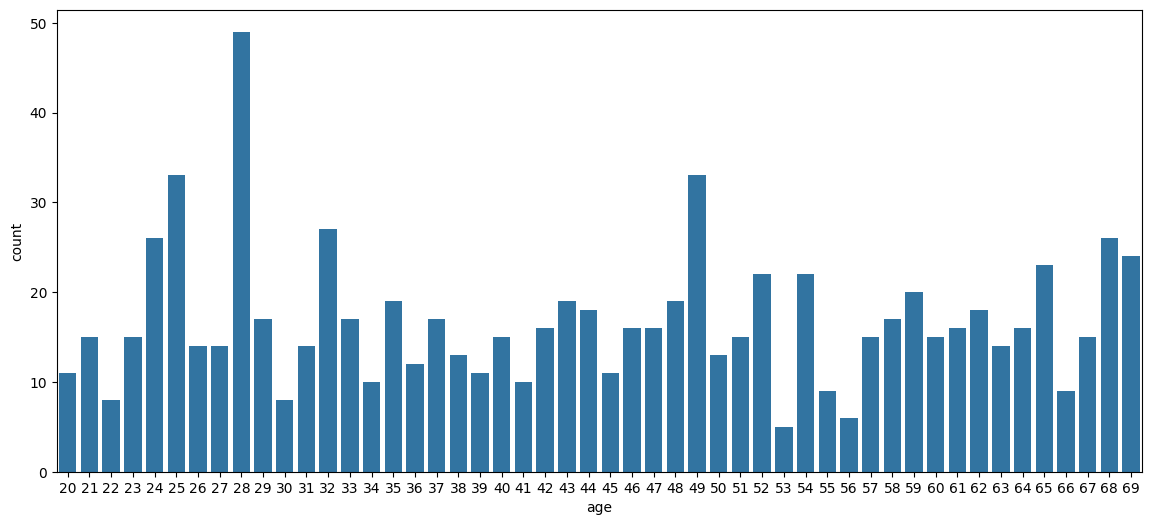

In [53]:
plt.figure(figsize=(14,6))
sns.countplot(data = successes_comp, x = 'age')